In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv
import emcee
import corner

# Physical constants needed for calculations
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma_sb = 5.670374419e-5
Msun = 1.98847e33

# Conversion factor from electron-volts to erg
eV_to_erg = 1.602176634e-12

# Hydrogen ionization threshold: 13.6 eV
hydrogen_ionization_energy = 13.6 * eV_to_erg
hydrogen_ionization_frequency = hydrogen_ionization_energy / h

# Case-B total recombination coefficient at T = 10^4 K
alpha_B_H = 2.59e-13  # cm^3 s^-1

# Effective recombination coefficients for the Balmer lines
# at T = 10^4 K and ne = 10^6 cm^-3
alpha_eff_balmer = {
    "Ha": 1.16e-13,
    "Hb": 3.07e-14,
    "Hg": 1.29e-14,
    "Hd": 6.79e-15,
    "Halpha": 1.16e-13,
    "Hbeta": 3.07e-14,
    "Hgamma": 1.29e-14,
    "Hdelta": 6.79e-15
}

# Rest wavelengths of the Balmer lines in Angstrom
balmer_wavelengths_angstrom = {
    "Ha": 6563.0,
    "Hb": 4861.0,
    "Hg": 4340.0,
    "Hd": 4102.0,
    "Halpha": 6563.0,
    "Hbeta": 4861.0,
    "Hgamma": 4340.0,
    "Hdelta": 4102.0
}

In [92]:
def find_column(df, possible_names, required=True):
    """
    Search for a column name among several allowed alternatives.

    Input:
        - df: input DataFrame
        - possible_names: list of candidate column names
        - required: if True, raise an error when no match is found

    Output:
        - name of the matching column
    """

    for name in possible_names:
        if name in df.columns:
            return name

    if required:
        raise ValueError(
            f"None of the following columns were found: {possible_names}"
        )

    return None


def read_transitions(transition_file):
    """
    Read the transition catalogue.

    Input:
        - transition_file: ASCII file containing line properties

    Processing:
        - read line name
        - read ionization energy
        - read ionization threshold frequency

    Output:
        - DataFrame containing transition information
    """

    line_names, ionization_energy, ionization_frequency = np.genfromtxt(
        transition_file,
        dtype=("U50", float, float),
        unpack=True
    )

    return pd.DataFrame({
        "line_name": line_names,
        "E_ion": ionization_energy,
        "nu_ion": ionization_frequency
    })


def extract_observed_lines(row, norm_columns, relative_error):
    """
    Extract all valid observed emission lines for one source.

    Input:
        - row: selected blazar entry
        - norm_columns: columns containing normalized line luminosities
        - relative_error: default fractional uncertainty

    Processing:
        - discard missing or non-physical measurements
        - convert normalized luminosities into physical units
        - recover measured uncertainties when available
        - otherwise assign a default relative uncertainty

    Output:
        - DataFrame containing observed line luminosities
    """

    results = []

    for column in norm_columns:

        value = row[column]

        # Ignore missing or non-positive measurements
        if pd.isna(value) or value <= 0:
            continue

        line_name = column.replace("_norm", "")
        uncertainty_column = f"{line_name}_norm_unc"

        # Convert luminosity to physical units
        line_luminosity = value * 1e42

        # Use measured uncertainty if available
        if (
            uncertainty_column in row.index
            and pd.notna(row[uncertainty_column])
            and row[uncertainty_column] > 0
        ):
            sigma_luminosity = row[uncertainty_column] * 1e42

        # Otherwise adopt a fixed relative uncertainty
        else:
            sigma_luminosity = relative_error * line_luminosity

        results.append({
            "line_name": line_name,
            "norm_value": value,
            "L_line_obs": line_luminosity,
            "sigma_L": sigma_luminosity
        })

    return pd.DataFrame(results)


def prepare_blazar_data(
    target_label,
    line_file,
    transition_file,
    relative_error,
    exclude_lines=None
):
    """
    Prepare the observational dataset for a single blazar.

    exclude_lines:
        lista opzionale di righe di emissione da escludere dai calcoli.
        Esempio: ["MgII", "CIV", "Hbeta"]
    """

    df_catalogue = pd.read_csv(line_file)

    df_transitions = read_transitions(transition_file)

    source_column = find_column(
        df_catalogue,
        ["label", "file_name", "name", "nome", "blazar"]
    )

    norm_columns = [
        col for col in df_catalogue.columns
        if col.endswith("_norm")
    ]

    df_all_sources = (
        df_catalogue
        .rename(columns={source_column: "label"})
        .copy()
    )

    df_all_sources["label"] = (
        df_all_sources["label"]
        .astype(str)
        .str.strip()
    )

    target_label_clean = str(target_label).strip()

    df_match = df_all_sources[
        df_all_sources["label"] == target_label_clean
    ].copy()

    if df_match.empty:
        df_match = df_all_sources[
            df_all_sources["label"].str.contains(
                target_label_clean,
                case=False,
                na=False
            )
        ].copy()

    if df_match.empty:

        print("Available labels:")
        print(
            df_all_sources["label"]
            .drop_duplicates()
            .sort_values()
            .tolist()
        )

        raise ValueError(
            f"No blazar found for target_label = '{target_label}'"
        )

    if len(df_match) > 1:

        print("Multiple compatible sources found:")
        print(df_match["label"].tolist())
        print("Using the first match.")

    selected_row = df_match.iloc[0]

    df_observed = extract_observed_lines(
        selected_row,
        norm_columns,
        relative_error
    )

    # ------------------------------------------------------
    # Exclude selected emission lines from this blazar
    # ------------------------------------------------------
    if exclude_lines is not None and len(exclude_lines) > 0:

        exclude_lines = [
            str(line).strip()
            for line in exclude_lines
        ]

        df_observed = df_observed[
            ~df_observed["line_name"].isin(exclude_lines)
        ].copy()

        print("Excluded emission lines:")
        print(exclude_lines)

    df_observed = df_observed.merge(
        df_transitions[["line_name", "E_ion", "nu_ion"]],
        on="line_name",
        how="left"
    )

    df_observed["sigma_L"] = pd.to_numeric(
        df_observed["sigma_L"],
        errors="coerce"
    )

    df_observed.loc[
        df_observed["sigma_L"].isna()
        | (df_observed["sigma_L"] <= 0),
        "sigma_L"
    ] = relative_error * df_observed["L_line_obs"]

    print(f"Selected blazar: {selected_row['label']}")
    print(
        f"Number of observed lines used: {len(df_observed)}"
    )

    print("Lines used:")
    print(df_observed["line_name"].tolist())

    return (
        df_all_sources,
        df_transitions,
        df_observed
    )

In [93]:
def build_ss_spectrum(
    black_hole_mass_solar,
    eddington_accretion_rate,
    cfg
):
    """
    Compute the spectral energy distribution of a
    Shakura-Sunyaev thin accretion disk.

    Input:
        - black_hole_mass_solar:
          black-hole mass in solar masses

        - eddington_accretion_rate:
          accretion rate normalized to the Eddington value

        - cfg:
          configuration dictionary containing numerical
          and physical model parameters

    Processing:
        - compute Eddington luminosity
        - derive physical mass accretion rate
        - construct radial disk grid
        - compute disk temperature profile
        - evaluate blackbody emission at each radius
        - integrate emission over the entire disk

    Output:
        - frequency array
        - monochromatic luminosity spectrum (Lnu)
        - spectral energy distribution (nuLnu)
        - dictionary containing model information
    """

    # Convert black-hole mass from solar masses to CGS units
    black_hole_mass = black_hole_mass_solar * Msun

    # Retrieve model parameters from configuration
    radiative_efficiency = cfg["eta"]

    number_radial_points = cfg["Nr"]

    number_frequency_points = cfg["Nnu_ss"]

    minimum_frequency = cfg["nu_min_ss"]
    maximum_frequency = cfg["nu_max_ss"]

    # Compute Eddington luminosity
    eddington_luminosity = (
        1.3e38 * black_hole_mass_solar
    )

    # Compute total disk luminosity
    disk_luminosity = (
        eddington_accretion_rate
        * eddington_luminosity
    )

    # Convert luminosity into physical mass accretion rate
    mass_accretion_rate = (
        disk_luminosity
        / (radiative_efficiency * c**2)
    )

    # Compute characteristic disk radii
    schwarzschild_radius = (
        2 * G * black_hole_mass
        / c**2
    )

    inner_radius = 3 * schwarzschild_radius

    outer_radius = 3000 * schwarzschild_radius

    # Construct logarithmically spaced radial grid
    radius_grid = np.logspace(
        np.log10(inner_radius),
        np.log10(outer_radius),
        number_radial_points
    )

    # Inner-boundary correction factor
    boundary_factor = (
        1.0
        - np.sqrt(inner_radius / radius_grid)
    )

    boundary_factor = np.clip(
        boundary_factor,
        0.0,
        None
    )

    # Compute effective temperature profile
    temperature_profile = (
        (
            3
            * G
            * black_hole_mass
            * mass_accretion_rate
        )
        /
        (
            8
            * np.pi
            * sigma_sb
            * radius_grid**3
        )
        * boundary_factor
    )**0.25

    # Construct frequency grid
    frequency_grid = np.logspace(
        np.log10(minimum_frequency),
        np.log10(maximum_frequency),
        number_frequency_points
    )

    # Allocate Planck-function matrix
    planck_function = np.zeros(
        (
            number_frequency_points,
            number_radial_points
        )
    )

    # Evaluate blackbody emission at each radius
    for j in range(number_radial_points):

        if temperature_profile[j] <= 0:
            continue

        x = (
            h * frequency_grid
            /
            (
                kB
                * temperature_profile[j]
            )
        )

        # Prevent numerical overflow
        x = np.clip(
            x,
            1e-12,
            700.0
        )

        planck_function[:, j] = (
            (
                2
                * h
                * frequency_grid**3
                / c**2
            )
            /
            (
                np.exp(x) - 1.0
            )
        )

    # Integrate the contribution of all disk annuli
    integrand = (
        radius_grid[None, :]
        * planck_function
    )

    integrated_intensity = np.trapezoid(
        integrand,
        radius_grid,
        axis=1
    )

    # Convert intensity into luminosity
    luminosity_spectrum = (
        4                                        #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! (mettere 8) per anisotropia
        * np.pi**2
        * integrated_intensity
    )

    # Compute spectral energy distribution
    spectral_energy_distribution = (
        frequency_grid
        * luminosity_spectrum
    )

    # Store additional physical information
    model_info = {

        "regime": "SS",

        "black_hole_mass_solar":
            black_hole_mass_solar,

        "eddington_accretion_rate":
            eddington_accretion_rate,

        "eddington_luminosity":
            eddington_luminosity,

        "disk_luminosity":
            disk_luminosity,

        "mass_accretion_rate_cgs":
            mass_accretion_rate
    }

    return (
        frequency_grid,
        luminosity_spectrum,
        spectral_energy_distribution,
        model_info
    )

In [94]:
def bessel_k(order, argument):
    """
    Compute the modified Bessel function of the second kind.

    Input:
        - order: order of the Bessel function
        - argument: value at which the function is evaluated

    Output:
        - value of the modified Bessel function
    """

    return kv(order, argument)


def adaf_thermal_function(theta_e):
    """
    Compute the ADAF thermal correction function.

    Input:
        - theta_e: dimensionless electron temperature

    Processing:
        - evaluate the Bessel function required by the ADAF model
        - check that the result is finite and physically valid
        - compute the thermal correction term

    Output:
        - thermal correction factor
    """

    bessel_value = bessel_k(2, 1.0 / theta_e)

    if not np.isfinite(bessel_value) or bessel_value <= 0:
        return np.nan

    return (
        (1.0 / bessel_value)
        * (2.0 + 2.0 * theta_e + 1.0 / theta_e)
        * np.exp(-1.0 / theta_e)
    )


def adaf_temperature_equations(
    variables,
    accretion_rate,
    black_hole_mass,
    beta,
    cfg
):
    """
    Define the nonlinear ADAF equations solved by the root finder.

    Input:
        - variables: numerical variables explored by the solver
        - accretion_rate: Eddington-scaled accretion rate
        - black_hole_mass: black-hole mass in solar masses
        - beta: gas-to-total pressure parameter
        - cfg: configuration dictionary

    Processing:
        - transform solver variables into physical quantities
        - compute heating and cooling terms
        - compute synchrotron, Compton, and bremsstrahlung contributions
        - return the residuals of the ADAF balance equations

    Output:
        - list of three residuals to be driven close to zero
    """

    # Reject invalid numerical inputs
    if not np.all(np.isfinite(variables)):
        return [1e99, 1e99, 1e99]

    # Reject non-physical model parameters
    if (
        accretion_rate <= 0
        or black_hole_mass <= 0
        or beta <= 0
        or beta >= 1
    ):
        return [1e99, 1e99, 1e99]

    # Avoid extreme solver excursions
    if np.any(np.abs(variables) > 1e3):
        return [1e99, 1e99, 1e99]

    alpha = cfg["alfa"]
    inner_radius = cfg["rmin"]
    outer_radius = cfg["rmax"]
    electron_heating_fraction = cfg["delta"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    temperature_normalization = cfg["tnorm"]

    # Squared variables guarantee positive physical quantities
    advection_fraction = variables[2]**2
    synchrotron_parameter = 1e3 * variables[1]**2
    theta_e = variables[0]**2

    if (
        advection_fraction <= 0
        or synchrotron_parameter <= 0
        or theta_e <= 1e-12
    ):
        return [1e99, 1e99, 1e99]

    thermal_factor = adaf_thermal_function(theta_e)

    if not np.isfinite(thermal_factor):
        return [1e99, 1e99, 1e99]

    # ADAF scaling coefficients
    synchrotron_scale_1 = (
        1.42e9
        * alpha**(-0.5)
        * np.sqrt(1 - beta)
        * c1**(-0.5)
        * c3**0.5
    )

    synchrotron_scale_2 = (
        1.19e-13
        * synchrotron_parameter
    )

    # Ion heating term
    ion_heating = (
        1.2e4
        * thermal_factor
        * alpha**(-2)
        * c1**(-2)
        * c3
        * beta
        * black_hole_mass
        * accretion_rate**2
        / inner_radius
    )

    # Direct electron heating term
    electron_heating = (
        electron_heating_fraction
        * 9.39e4
        * ((1 - beta) / advection_fraction)
        * c3
        * black_hole_mass
        * accretion_rate
        / inner_radius
    )

    total_heating = ion_heating + electron_heating

    peak_synchrotron_frequency = (
        synchrotron_scale_1
        * synchrotron_scale_2
        * black_hole_mass**(-0.5)
        * accretion_rate**0.5
        * (theta_e / temperature_normalization)**2
        * inner_radius**(-5/4)
    )

    if (
        not np.isfinite(peak_synchrotron_frequency)
        or peak_synchrotron_frequency <= 0
    ):
        return [1e99, 1e99, 1e99]

    synchrotron_power = (
        53.0
        * (synchrotron_parameter / 1000.0)**3
        * (theta_e / (1e9 * temperature_normalization))**7
        * black_hole_mass**0.5
        * accretion_rate**1.5
    )

    compton_amplification = (
        1
        + 4 * theta_e
        + 16 * theta_e**2
    )

    optical_depth = (
        23.87
        * accretion_rate
    )

    if optical_depth <= 0 or compton_amplification <= 1:
        return [1e99, 1e99, 1e99]

    compton_slope = (
        -np.log(optical_depth)
        / np.log(compton_amplification)
    )

    try:
        compton_base = (
            6.2e7
            * (theta_e / (1e9 * temperature_normalization))
            / (peak_synchrotron_frequency * 1e-12)
        )

        if (
            compton_base <= 0
            or not np.isfinite(compton_base)
        ):
            return [1e99, 1e99, 1e99]

        compton_factor = (
            compton_base**(1 - compton_slope)
            - 1
        )

        compton_power = (
            (synchrotron_power / 0.71)
            / (1 - compton_slope)
            * compton_factor
        )

    except Exception:
        return [1e99, 1e99, 1e99]

    # Bremsstrahlung correction factor
    if theta_e < 1:
        bremsstrahlung_factor = (
            4
            * np.sqrt(2 * theta_e / np.pi**3)
            * (1 + 1.781 * theta_e**1.34)
        )

    else:
        bremsstrahlung_factor = (
            (9 * theta_e / (2 * np.pi))
            * (
                np.log(1.123 * theta_e + 0.48)
                + 1.5
            )
        )

    bremsstrahlung_power = (
        4.78
        * alpha**(-2)
        * c1**(-2)
        * np.log(outer_radius / inner_radius)
        * bremsstrahlung_factor
        * black_hole_mass
        * accretion_rate**2
    )

    # First residual: heating minus total cooling
    residual_energy = (
        total_heating
        - synchrotron_power
        - compton_power
        - bremsstrahlung_power
    )

    # Second residual: advected energy balance
    residual_advection = (
        (1 - advection_fraction)
        * 9.39e4
        * ((1 - beta) / advection_fraction)
        * c3
        * black_hole_mass
        * accretion_rate
        / inner_radius
        - total_heating
    )

    bessel_value = bessel_k(2, 1 / theta_e)
    logarithm_argument = theta_e**3 * bessel_value

    if (
        not np.isfinite(logarithm_argument)
        or logarithm_argument <= 0
    ):
        return [1e99, 1e99, 1e99]

    transformed_synchrotron_parameter = (
        synchrotron_parameter**(1/3)
    )

    # Third residual: synchrotron self-absorption condition
    residual_synchrotron = (
        transformed_synchrotron_parameter
        + 1.852 * np.log(transformed_synchrotron_parameter)
        - 10.36
        - 0.26 * np.log(black_hole_mass * accretion_rate)
        + 0.26 * np.log(logarithm_argument)
    )

    residuals = np.array(
        [
            residual_energy,
            residual_synchrotron,
            residual_advection
        ],
        dtype=float
    )

    if not np.all(np.isfinite(residuals)):
        return [1e99, 1e99, 1e99]

    return residuals.tolist()


def build_adaf_spectrum_from_solution(
    electron_temperature,
    advection_fraction,
    synchrotron_parameter,
    black_hole_mass,
    accretion_rate,
    beta,
    cfg
):
    """
    Compute the ADAF spectrum after the physical solution is found.

    Input:
        - electron_temperature: electron temperature parameter
        - advection_fraction: fraction of energy advected inward
        - synchrotron_parameter: synchrotron self-absorption parameter
        - black_hole_mass: black-hole mass in solar masses
        - accretion_rate: Eddington-scaled accretion rate
        - beta: gas-to-total pressure parameter
        - cfg: configuration dictionary

    Processing:
        - build the frequency grid
        - compute synchrotron emission
        - compute Comptonized synchrotron emission
        - compute bremsstrahlung emission
        - sum all components

    Output:
        - logarithmic frequency grid
        - logarithmic spectral energy distribution
    """

    alpha = cfg["alfa"]
    inner_radius = cfg["rmin"]
    outer_radius = cfg["rmax"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    temperature_normalization = cfg["tnorm"]

    minimum_frequency = cfg["nu_min_adaf"]
    maximum_frequency = cfg["nu_max_adaf"]
    number_frequency_points = cfg["Nnu_adaf"]

    log_frequency_grid = np.linspace(
        np.log10(minimum_frequency),
        np.log10(maximum_frequency),
        number_frequency_points
    )

    frequency_grid = 10**log_frequency_grid

    theta_e = (
        temperature_normalization
        * electron_temperature
    )

    if electron_temperature <= 0 or theta_e <= 0:
        raise RuntimeError("Invalid ADAF temperature")

    synchrotron_scale_1 = (
        1.42e9
        * alpha**(-0.5)
        * np.sqrt(1 - beta)
        * c1**(-0.5)
        * c3**0.5
    )

    synchrotron_scale_2 = (
        1.19e-13
        * synchrotron_parameter
    )

    synchrotron_scale_3 = 1.05e-24

    compton_amplification = (
        1
        + 4 * theta_e
        + 16 * theta_e**2
    )

    optical_depth = (
        23.87
        * accretion_rate
    )

    if optical_depth <= 0 or compton_amplification <= 1:
        raise RuntimeError("Invalid ADAF Compton parameters")

    compton_slope = (
        -np.log(optical_depth)
        / np.log(compton_amplification)
    )

    log_peak_synchrotron_frequency = np.log10(
        synchrotron_scale_1
        * synchrotron_scale_2
        * black_hole_mass**(-0.5)
        * accretion_rate**0.5
        * electron_temperature**2
        * inner_radius**(-5/4)
    )

    log_maximum_compton_frequency = (
        np.log10(electron_temperature)
        + 10.796
    )

    log_synchrotron_peak_luminosity = (
        3 * np.log10(synchrotron_scale_1 * synchrotron_scale_2)
        + np.log10(synchrotron_scale_3)
        - (7/4) * np.log10(inner_radius)
        + np.log10(black_hole_mass**0.5 * accretion_rate**1.5)
        + 7 * np.log10(electron_temperature)
    )

    log_synchrotron_luminosity = np.zeros(
        number_frequency_points
    )

    log_compton_luminosity = np.zeros(
        number_frequency_points
    )

    log_bremsstrahlung_luminosity = np.zeros(
        number_frequency_points
    )

    if theta_e < 1:
        bremsstrahlung_factor = (
            4
            * np.sqrt(2 * theta_e / np.pi**3)
            * (1 + 1.781 * theta_e**1.34)
        )

    else:
        bremsstrahlung_factor = (
            (9 * theta_e / (2 * np.pi))
            * (
                np.log(1.123 * theta_e + 0.48)
                + 1.5
            )
        )

    for i in range(number_frequency_points):

        # Synchrotron component below the peak frequency
        if log_frequency_grid[i] < log_peak_synchrotron_frequency:

            log_synchrotron_luminosity[i] = (
                np.log10(synchrotron_scale_3)
                + (8/5) * np.log10(
                    synchrotron_scale_1
                    * synchrotron_scale_2
                )
                + np.log10(
                    black_hole_mass**(6/5)
                    * accretion_rate**(4/5)
                )
                + (21/5) * np.log10(electron_temperature)
                + (2/5) * log_frequency_grid[i]
            )

        # Comptonized synchrotron component above the peak
        if log_frequency_grid[i] > log_peak_synchrotron_frequency:

            compton_base = (
                log_synchrotron_peak_luminosity
                + (compton_slope - 1)
                * log_peak_synchrotron_frequency
                - compton_slope
                * log_frequency_grid[i]
            )

            compton_cutoff = (
                -(
                    10**(
                        log_frequency_grid[i]
                        - log_maximum_compton_frequency
                    )
                )
                / np.log(10)
            )

            log_compton_luminosity[i] = (
                compton_base
                + compton_cutoff
            )

        bremsstrahlung_base = (
            24.36
            - 2 * np.log10(alpha * c1)
            + np.log10(
                np.log(outer_radius / inner_radius)
                * bremsstrahlung_factor
            )
            - np.log10(electron_temperature)
            + np.log10(
                black_hole_mass
                * accretion_rate**2
            )
        )

        bremsstrahlung_cutoff = (
            -(
                4.8e-11
                * frequency_grid[i]
                / electron_temperature
            )
            / np.log(10)
        )

        log_bremsstrahlung_luminosity[i] = (
            bremsstrahlung_base
            + bremsstrahlung_cutoff
        )

    # Total ADAF emission from all components
    total_flux = (
        10**log_synchrotron_luminosity
        + 10**log_compton_luminosity
        + 10**log_bremsstrahlung_luminosity
    )

    if (
        not np.all(np.isfinite(total_flux))
        or np.any(total_flux < 0)
    ):
        raise RuntimeError("Invalid ADAF flux")

    log_spectral_energy_distribution = (
        log_frequency_grid
        + np.log10(total_flux)
    )

    return (
        log_frequency_grid,
        log_spectral_energy_distribution
    )


def compute_adaf_spectral_data(
    black_hole_mass,
    accretion_rate,
    beta,
    cfg,
    verbose=False
):
    """
    Solve the ADAF equations and build the corresponding spectrum.

    Input:
        - black_hole_mass: black-hole mass in solar masses
        - accretion_rate: Eddington-scaled accretion rate
        - beta: gas-to-total pressure parameter
        - cfg: configuration dictionary
        - verbose: if True, print the current model parameters

    Processing:
        - initialize the root solver
        - solve the ADAF nonlinear equations
        - recover the physical ADAF quantities
        - compute the spectral energy distribution
        - convert logarithmic quantities into physical luminosities

    Output:
        - frequency grid
        - monochromatic luminosity spectrum
        - spectral energy distribution
        - model information dictionary
    """

    if verbose:
        print(
            f"ADAF -> m={black_hole_mass:.3e}, "
            f"mdot={accretion_rate:.3e}, beta={beta}"
        )

    initial_solution = cfg["root_y0"]

    solution = root(
        adaf_temperature_equations,
        initial_solution,
        args=(
            accretion_rate,
            black_hole_mass,
            beta,
            cfg
        ),
        tol=cfg["root_tol"]
    )

    if not solution.success:
        raise RuntimeError(
            f"Root did not converge for "
            f"m={black_hole_mass:.3e}, "
            f"mdot={accretion_rate:.3e}"
        )

    solver_variables = solution.x

    theta_e = solver_variables[0]**2

    electron_temperature = (
        theta_e
        / cfg["tnorm"]
    )

    synchrotron_parameter = (
        1e3
        * solver_variables[1]**2
    )

    advection_fraction = (
        solver_variables[2]**2
    )

    (
        log_frequency_grid,
        log_spectral_energy_distribution
    ) = build_adaf_spectrum_from_solution(
        electron_temperature,
        advection_fraction,
        synchrotron_parameter,
        black_hole_mass,
        accretion_rate,
        beta,
        cfg
    )

    frequency_grid = 10**log_frequency_grid

    log_luminosity_spectrum = (
        log_spectral_energy_distribution
        - log_frequency_grid
    )

    luminosity_spectrum = (
        10**log_luminosity_spectrum          #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    )

    spectral_energy_distribution = (
        frequency_grid
        * luminosity_spectrum
    )

    model_info = {

        "regime": "ADAF",

        "black_hole_mass":
            black_hole_mass,

        "accretion_rate":
            accretion_rate,

        "beta":
            beta,

        "electron_temperature":
            electron_temperature,

        "synchrotron_parameter":
            synchrotron_parameter,

        "advection_fraction":
            advection_fraction,

        "root_success":
            solution.success
    }

    return (
        frequency_grid,
        luminosity_spectrum,
        spectral_energy_distribution,
        model_info
    )


def build_adaf_spectrum(
    black_hole_mass_solar,
    eddington_accretion_rate,
    cfg
):
    """
    High-level wrapper for the ADAF spectrum.

    Input:
        - black_hole_mass_solar: black-hole mass in solar masses
        - eddington_accretion_rate: Eddington-scaled accretion rate
        - cfg: configuration dictionary

    Processing:
        - read the ADAF beta parameter from the configuration
        - solve the ADAF physical equations
        - remove invalid numerical values
        - sort the spectrum by increasing frequency

    Output:
        - cleaned frequency grid
        - cleaned luminosity spectrum
        - cleaned spectral energy distribution
        - ADAF model information
    """

    beta = cfg["beta_adaf"]

    (
        frequency_grid,
        luminosity_spectrum,
        spectral_energy_distribution,
        model_info
    ) = compute_adaf_spectral_data(
        black_hole_mass=black_hole_mass_solar,
        accretion_rate=eddington_accretion_rate,
        beta=beta,
        cfg=cfg,
        verbose=False
    )

    # Keep only finite and physically meaningful values
    valid_mask = (
        np.isfinite(frequency_grid)
        & np.isfinite(luminosity_spectrum)
        & np.isfinite(spectral_energy_distribution)
        & (frequency_grid > 0)
        & (luminosity_spectrum >= 0)
    )

    frequency_grid = frequency_grid[valid_mask]
    luminosity_spectrum = luminosity_spectrum[valid_mask]
    spectral_energy_distribution = (
        spectral_energy_distribution[valid_mask]
    )

    if len(frequency_grid) < 2:
        raise RuntimeError(
            "Invalid ADAF spectrum after filtering"
        )

    sorting_index = np.argsort(frequency_grid)

    return (
        frequency_grid[sorting_index],
        luminosity_spectrum[sorting_index],
        spectral_energy_distribution[sorting_index],
        model_info
    )

In [95]:
def compute_line_driving_quantities(
    frequency_grid,
    luminosity_spectrum,
    df_transitions,
    maximum_ionizing_frequency
):
    """
    Compute the physical quantity used to predict each emission line.

    Balmer lines (Ha, Hb, Hg, Hd):
        Q(H) = integral_[nu0,nu_max] Lnu/(h*nu) dnu

        L_line_without_cf =
            h * nu_line
            * (alpha_eff_line / alpha_B)
            * Q(H)

        where nu0 corresponds to the hydrogen ionization
        threshold of 13.6 eV.

    MgII, CIII, CIV, and all other non-Balmer lines:
        L_ion = integral_[nu_ion,nu_max] Lnu dnu

        L_line_without_cf = L_ion

        where nu_ion is read from dati.asc.

    The covering factor is applied later in
    predict_lines_from_unified_model().
    """

    results = []

    # ------------------------------------------------------
    # Hydrogen-ionizing photon rate Q(H)
    # Common to all four Balmer lines
    # ------------------------------------------------------
    hydrogen_mask = (
        (frequency_grid >= hydrogen_ionization_frequency)
        & (frequency_grid <= maximum_ionizing_frequency)
    )

    if np.sum(hydrogen_mask) < 2:

        Q_H = 0.0

    else:

        Q_H = np.trapezoid(
            luminosity_spectrum[hydrogen_mask]
            / (
                h
                * frequency_grid[hydrogen_mask]
            ),
            frequency_grid[hydrogen_mask]
        )

    # ------------------------------------------------------
    # Compute the quantity needed for each transition
    # ------------------------------------------------------
    for _, row in df_transitions.iterrows():

        line_name = str(row["line_name"]).strip()
        ionizing_frequency = row["nu_ion"]
        ionization_energy = row["E_ion"]

        # ==================================================
        # BALMER LINES: Case-B recombination prescription
        # ==================================================
        if line_name in alpha_eff_balmer:

            wavelength_angstrom = (
                balmer_wavelengths_angstrom[line_name]
            )

            # Convert Angstrom to cm
            wavelength_cm = (
                wavelength_angstrom
                * 1e-8
            )

            # Emitted-line frequency nu_line = c / lambda_line
            line_frequency = (
                c
                / wavelength_cm
            )

            effective_recombination_coefficient = (
                alpha_eff_balmer[line_name]
            )

            recombination_ratio = (
                effective_recombination_coefficient
                / alpha_B_H
            )

            # Balmer luminosity before applying the covering factor:
            #
            # h * nu_line
            # * (alpha_eff / alpha_B)
            # * integral Lnu/(h*nu) dnu
            line_luminosity_without_cf = (
                h
                * line_frequency
                * recombination_ratio
                * Q_H
            )

            results.append({
                "line_name": line_name,
                "E_ion": 13.6,
                "nu_ion": hydrogen_ionization_frequency,
                "Q_H": Q_H,
                "L_ion": np.nan,
                "nu_line": line_frequency,
                "alpha_eff": effective_recombination_coefficient,
                "alpha_B": alpha_B_H,
                "alpha_ratio": recombination_ratio,
                "L_line_without_cf":
                    line_luminosity_without_cf,
                "line_model": "Balmer_CaseB"
            })

        # ==================================================
        # NON-BALMER LINES: original Cf * Lion prescription
        # ==================================================
        else:

            if (
                not np.isfinite(ionizing_frequency)
                or ionizing_frequency
                >= maximum_ionizing_frequency
            ):

                ionizing_luminosity = 0.0

            else:

                valid_frequency_range = (
                    (frequency_grid >= ionizing_frequency)
                    & (
                        frequency_grid
                        <= maximum_ionizing_frequency
                    )
                )

                if np.sum(valid_frequency_range) < 2:

                    ionizing_luminosity = 0.0

                else:

                    ionizing_luminosity = np.trapezoid(
                        luminosity_spectrum[
                            valid_frequency_range
                        ],
                        frequency_grid[
                            valid_frequency_range
                        ]
                    )

            results.append({
                "line_name": line_name,
                "E_ion": ionization_energy,
                "nu_ion": ionizing_frequency,
                "Q_H": np.nan,
                "L_ion": ionizing_luminosity,
                "nu_line": np.nan,
                "alpha_eff": np.nan,
                "alpha_B": np.nan,
                "alpha_ratio": np.nan,
                "L_line_without_cf":
                    ionizing_luminosity,
                "line_model": "Cf_times_Lion"
            })

    return pd.DataFrame(results)


def build_unified_spectrum(
    log_black_hole_mass,
    log_accretion_rate,
    cfg
):
    """
    Build the continuum spectrum using either the ADAF or SS model.

    Input:
        - log_black_hole_mass: base-10 logarithm of black-hole mass
        - log_accretion_rate: base-10 logarithm of accretion rate
        - cfg: configuration dictionary

    Processing:
        - convert logarithmic parameters into physical values
        - compare the accretion rate with the regime threshold
        - use the ADAF spectrum at low accretion rate
        - use the SS spectrum at high accretion rate

    Output:
        - frequency grid
        - luminosity spectrum
        - spectral energy distribution
        - model information dictionary
    """

    black_hole_mass = 10**log_black_hole_mass
    accretion_rate = 10**log_accretion_rate

    # Select the accretion regime according to the accretion rate
    if log_accretion_rate < cfg["logmdot_switch"]:

        (
            frequency_grid,
            luminosity_spectrum,
            spectral_energy_distribution,
            model_info
        ) = build_adaf_spectrum(
            black_hole_mass_solar=black_hole_mass,
            eddington_accretion_rate=accretion_rate,
            cfg=cfg
        )

        regime = "ADAF"

    else:

        (
            frequency_grid,
            luminosity_spectrum,
            spectral_energy_distribution,
            model_info
        ) = build_ss_spectrum(
            black_hole_mass_solar=black_hole_mass,
            eddington_accretion_rate=accretion_rate,
            cfg=cfg
        )

        regime = "SS"

    model_info["regime"] = regime

    return (
        frequency_grid,
        luminosity_spectrum,
        spectral_energy_distribution,
        model_info
    )


def predict_lines_from_unified_model(
    log_black_hole_mass,
    log_accretion_rate,
    df_transitions,
    cfg
):
    """
    Predict emission-line luminosities from the unified accretion model.

    Balmer lines:
        L_line =
            h * nu_line
            * (alpha_eff / alpha_B)
            * Cf
            * integral_[nu0,nu_max] Lnu/(h*nu) dnu

        with h*nu0 = 13.6 eV.

    MgII, CIII and CIV:
        L_line =
            Cf
            * integral_[nu_ion,nu_max] Lnu dnu

        with nu_ion read from dati.asc.

    Output:
        - DataFrame containing model-predicted line luminosities
        - accretion regime used by the model
    """

    (
        frequency_grid,
        luminosity_spectrum,
        spectral_energy_distribution,
        model_info
    ) = build_unified_spectrum(
        log_black_hole_mass=log_black_hole_mass,
        log_accretion_rate=log_accretion_rate,
        cfg=cfg
    )

    df_line_model = (
        compute_line_driving_quantities(
            frequency_grid,
            luminosity_spectrum,
            df_transitions,
            maximum_ionizing_frequency=cfg["nu_max_ion"]
        )
    )

    # Select the BLR covering factor for the active regime
    if model_info["regime"] == "ADAF":

        covering_factor = cfg["cf_blr_adaf"]

    else:

        covering_factor = cfg["cf_blr_ss"]

    # Apply the covering factor.
    #
    # For Balmer lines:
    #   L_line_mod =
    #       Cf * h*nu_line*(alpha_eff/alpha_B)*Q(H)
    #
    # For MgII, CIII and CIV:
    #   L_line_mod = Cf * L_ion
    df_line_model["L_line_mod"] = (
        covering_factor
        * df_line_model["L_line_without_cf"]
    )

    df_line_model["regime"] = (
        model_info["regime"]
    )

    return (
        df_line_model,
        model_info["regime"]
    )

def compare_old_new_balmer(                           #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    log_black_hole_mass,
    log_accretion_rate,
    df_transitions,
    df_observed,
    cfg
):
    """
    Compare the old and new prescriptions for the Balmer lines
    at exactly the same values of logM and logmdot.

    OLD:
        L_line = Cf * integral Lnu dnu
        using the original nu_ion from dati.asc

    NEW:
        L_line =
            h * nu_line
            * (alpha_eff / alpha_B)
            * Cf
            * integral Lnu/(h*nu) dnu

        using the common hydrogen threshold of 13.6 eV.
    """

    (
        frequency_grid,
        luminosity_spectrum,
        spectral_energy_distribution,
        model_info
    ) = build_unified_spectrum(
        log_black_hole_mass=log_black_hole_mass,
        log_accretion_rate=log_accretion_rate,
        cfg=cfg
    )

    # ------------------------------------------------------
    # Covering factor
    # ------------------------------------------------------

    if model_info["regime"] == "ADAF":

        covering_factor = cfg["cf_blr_adaf"]

    else:

        covering_factor = cfg["cf_blr_ss"]

    # ------------------------------------------------------
    # NEW MODEL: Q(H)
    # common to all Balmer lines
    # ------------------------------------------------------

    hydrogen_mask = (
        (frequency_grid >= hydrogen_ionization_frequency)
        & (frequency_grid <= cfg["nu_max_ion"])
    )

    if np.sum(hydrogen_mask) < 2:

        Q_H = 0.0

    else:

        Q_H = np.trapezoid(
            luminosity_spectrum[hydrogen_mask]
            / (
                h
                * frequency_grid[hydrogen_mask]
            ),
            frequency_grid[hydrogen_mask]
        )

    print("OLD vs NEW BALMER-LINE CHECK")

    print(
        f"logM    = {log_black_hole_mass:.4f}"
    )

    print(
        f"logmdot = {log_accretion_rate:.4f}"
    )

    print(
        f"regime  = {model_info['regime']}"
    )

    print(
        f"Cf      = {covering_factor:.4f}"
    )

    print(
        f"Hydrogen threshold = 13.6 eV"
    )

    print(
        f"nu_0 = {hydrogen_ionization_frequency:.4e} Hz"
    )

    print(
        f"Q(H) = {Q_H:.4e} photons/s"
    )

    # ------------------------------------------------------
    # Balmer lines only
    # ------------------------------------------------------

    balmer_names = [
        "Ha",
        "Hb",
        "Hg",
        "Hd",
        "Halpha",
        "Hbeta",
        "Hgamma",
        "Hdelta"
    ]

    for _, row in df_transitions.iterrows():

        line_name = str(
            row["line_name"]
        ).strip()

        if line_name not in balmer_names:
            continue


        # ==================================================
        # OBSERVED LINE LUMINOSITY
        # ==================================================

        observed_match = df_observed[
            df_observed["line_name"] == line_name
        ]

        if len(observed_match) == 0:

            observed_Lline = np.nan
            observed_sigma = np.nan

        else:

            observed_Lline = (
                observed_match.iloc[0]["L_line_obs"]
            )

            observed_sigma = (
                observed_match.iloc[0]["sigma_L"]
            )
        # ==================================================
        # OLD MODEL
        # ==================================================

        old_ionizing_frequency = (
            row["nu_ion"]
        )

        old_mask = (
            (frequency_grid >= old_ionizing_frequency)
            & (
                frequency_grid
                <= cfg["nu_max_ion"]
            )
        )

        if np.sum(old_mask) < 2:

            old_Lion = 0.0

        else:

            old_Lion = np.trapezoid(
                luminosity_spectrum[old_mask],
                frequency_grid[old_mask]
            )

        old_Lline = (
            covering_factor
            * old_Lion
        )

        # ==================================================
        # NEW CASE-B MODEL
        # ==================================================

        wavelength_angstrom = (
            balmer_wavelengths_angstrom[
                line_name
            ]
        )

        wavelength_cm = (
            wavelength_angstrom
            * 1e-8
        )

        line_frequency = (
            c
            / wavelength_cm
        )

        alpha_eff = (
            alpha_eff_balmer[
                line_name
            ]
        )

        alpha_ratio = (
            alpha_eff
            / alpha_B_H
        )

        line_photon_energy = (
            h
            * line_frequency
        )

        new_Lline = (
            line_photon_energy
            * alpha_ratio
            * covering_factor
            * Q_H
        )


        # ==================================================
        # COMPARISON WITH OBSERVATIONS
        # ==================================================

        if (
            np.isfinite(observed_Lline)
            and observed_Lline > 0
        ):

            old_over_obs = (
                old_Lline
                / observed_Lline
            )

            new_over_obs = (
                new_Lline
                / observed_Lline
            )

            old_residual = (
                observed_Lline
                - old_Lline
            )

            new_residual = (
                observed_Lline
                - new_Lline
            )

        else:

            old_over_obs = np.nan
            new_over_obs = np.nan
            old_residual = np.nan
            new_residual = np.nan

        # ==================================================
        # OLD / NEW RATIO
        # ==================================================

        if old_Lline > 0:

            new_over_old = (
                new_Lline
                / old_Lline
            )

        else:

            new_over_old = np.nan




        print(
            f"{line_name:8s} | "
            f"old nu_ion = {old_ionizing_frequency:.4e} Hz"
        )

        print(
            f"         | "
            f"OLD Lion  = {old_Lion:.4e} erg/s"
        )

        print(
            f"         | "
            f"OLD Lline = {old_Lline:.4e} erg/s"
        )

        print(
            f"         | "
            f"nu_line   = {line_frequency:.4e} Hz"
        )

        print(
            f"         | "
            f"h nu_line = {line_photon_energy:.4e} erg"
        )

        print(
            f"         | "
            f"alpha_eff = {alpha_eff:.4e} cm^3/s"
        )

        print(
            f"         | "
            f"alpha_eff / alpha_B = "
            f"{alpha_ratio:.4e}"
        )

        print(
            f"         | "
            f"NEW Lline = {new_Lline:.4e} erg/s"
        )


        print(
            f"         | "
            f"OBS Lline = {observed_Lline:.4e} erg/s"
        )

        print(
            f"         | "
            f"OBS sigma = {observed_sigma:.4e} erg/s"
        )

        print(
            f"         | "
            f"OLD / OBS = {old_over_obs:.4e}"
        )

        print(
            f"         | "
            f"NEW / OBS = {new_over_obs:.4e}"
        )

        print(
            f"         | "
            f"OLD residual = {old_residual:.4e} erg/s"
        )

        print(
            f"         | "
            f"NEW residual = {new_residual:.4e} erg/s"
        )


        print(
            f"         | "
            f"NEW / OLD = {new_over_old:.4e}"
        )

        print("-" * 100)

    print("=" * 100)
    print()

In [96]:
def log_gaussian_prior(value, mean, standard_deviation):
    """
    Compute the logarithm of a Gaussian prior probability.

    Input:
        - value: parameter value to be evaluated
        - mean: mean value of the Gaussian prior
        - standard_deviation: width of the Gaussian prior

    Processing:
        - measure the distance between the parameter value and the prior mean
        - normalize this distance by the prior standard deviation
        - compute the logarithm of the Gaussian probability density

    Output:
        - log-prior probability for the input value
    """

    return (
        -0.5
        * ((value - mean) / standard_deviation)**2
        - np.log(
            standard_deviation
            * np.sqrt(2 * np.pi)
        )
    )


def log_prior(parameter_vector, cfg):
    """
    Compute the total log-prior probability of the model parameters.

    Input:
        - parameter_vector: pair containing log black-hole mass
          and log accretion rate
        - cfg: configuration dictionary containing the prior parameters

    Processing:
        - extract log black-hole mass and log accretion rate
        - evaluate a Gaussian prior on each parameter
        - assume that the two priors are independent
        - sum the two log-prior probabilities

    Output:
        - total log-prior probability
    """

    (
        log_black_hole_mass,
        log_accretion_rate
    ) = parameter_vector

    # Gaussian prior on black-hole mass
    log_prior_mass = log_gaussian_prior(
        log_black_hole_mass,
        cfg["prior_logm_mu"],
        cfg["prior_logm_sigma"]
    )

    # Gaussian prior on accretion rate
    log_prior_accretion_rate = log_gaussian_prior(
        log_accretion_rate,
        cfg["prior_logmdot_mu"],
        cfg["prior_logmdot_sigma"]
    )

    # Since the priors are independent, their logarithms are summed
    return (
        log_prior_mass
        + log_prior_accretion_rate
    )


def log_likelihood(
    parameter_vector,
    df_observed,
    df_transitions,
    cfg
):
    """
    Compute the Gaussian log-likelihood of the observed line luminosities.

    Input:
        - parameter_vector: pair containing log black-hole mass
          and log accretion rate
        - df_observed: observed emission-line luminosities
        - df_transitions: transition catalogue
        - cfg: configuration dictionary

    Processing:
        - build the unified SS or ADAF model
        - predict model emission-line luminosities
        - match observed and modelled lines by line name
        - compute residuals between observed and predicted luminosities
        - weight the residuals by the observational uncertainties

    Output:
        - Gaussian log-likelihood
    """

    (
        log_black_hole_mass,
        log_accretion_rate
    ) = parameter_vector

    try:

        (
            df_model,
            regime
        ) = predict_lines_from_unified_model(
            log_black_hole_mass=log_black_hole_mass,
            log_accretion_rate=log_accretion_rate,
            df_transitions=df_transitions,
            cfg=cfg
        )

    except Exception:

        # Invalid physical or numerical models are rejected
        return -np.inf

    if df_model is None or df_model.empty:
        return -np.inf

    if not np.all(
        np.isfinite(df_model["L_line_mod"].values)
    ):
        return -np.inf

    # Match observed and modelled line luminosities
    df_comparison = df_observed.merge(
        df_model[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    # Keep only valid measurements and model predictions
    df_comparison = df_comparison[
        df_comparison["L_line_obs"].notna()
        & df_comparison["sigma_L"].notna()
        & df_comparison["L_line_mod"].notna()
        & np.isfinite(df_comparison["L_line_mod"])
        & (df_comparison["L_line_mod"] >= 0)
        & (df_comparison["sigma_L"] > 0)
    ].copy()

    if len(df_comparison) == 0:
        return -np.inf

    # Difference between observed and modelled line luminosities
    residuals = (
        df_comparison["L_line_obs"].values
        - df_comparison["L_line_mod"].values
    )

    observational_uncertainties = (
        df_comparison["sigma_L"].values
    )

    """
    print("\n========== CHECK LUMINOSITIES ==========")                           #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    print( 
        f"logM = {log_black_hole_mass:.4f} | "
        f"logmdot = {log_accretion_rate:.4f} | "
        f"regime = {regime}"
    )
    for _, row in df_comparison.iterrows():
        print(
            f"{row['line_name']:12s} | "
            f"L_obs = {row['L_line_obs']:.4e} erg/s | "
            f"L_mod = {row['L_line_mod']:.4e} erg/s | "
            f"sigma = {row['sigma_L']:.4e} erg/s | "
            f"residual = {(row['L_line_obs'] - row['L_line_mod']):.4e} erg/s"
        )
    print("========================================\n")
    """
    
    if (
        not np.all(np.isfinite(residuals))
        or not np.all(np.isfinite(observational_uncertainties))
    ):
        return -np.inf

    # Gaussian log-likelihood
    return (
        -0.5
        * np.sum(
            (residuals / observational_uncertainties)**2
            + np.log(
                2
                * np.pi
                * observational_uncertainties**2
            )
        )
    )

In [97]:
def log_posterior(
    parameter_vector,
    df_observed,
    df_transitions,
    cfg
):
    """
    Compute the log-posterior probability.

    Input:
        - parameter_vector: pair containing log black-hole mass
          and log accretion rate
        - df_observed: observed emission-line luminosities
        - df_transitions: transition catalogue
        - cfg: configuration dictionary

    Processing:
        - compute the log-prior
        - reject impossible or invalid prior regions
        - compute the log-likelihood
        - reject invalid likelihood values
        - add log-prior and log-likelihood

    Output:
        - total log-posterior probability
    """

    prior_value = log_prior(
        parameter_vector,
        cfg
    )

    if not np.isfinite(prior_value):

        return -np.inf

    likelihood_value = log_likelihood(
        parameter_vector,
        df_observed,
        df_transitions,
        cfg
    )

    if not np.isfinite(likelihood_value):

        return -np.inf

    return (
        prior_value
        + likelihood_value
    )

In [98]:
def initialize_walkers(cfg):
    """
    Initialize the MCMC walkers.

    Input:
        - cfg: configuration dictionary containing the random seed,
          the number of walkers, the initial guesses, and the spreads

    Processing:
        - create a random-number generator
        - draw trial positions around the initial guesses
        - keep only positions with finite prior probability
        - repeat until all walkers are initialized

    Output:
        - array of initial walker positions
    """

    random_generator = np.random.default_rng(
        cfg["random_seed"]
    )

    initial_positions = []

    while len(initial_positions) < cfg["nwalkers"]:

        trial_position = np.array([
            random_generator.normal(
                cfg["guess_logm"],
                cfg["spread_logm"]
            ),
            random_generator.normal(
                cfg["guess_logmdot"],
                cfg["spread_logmdot"]
            )
        ])

        # Accept only physically allowed starting points
        if np.isfinite(
            log_prior(
                trial_position,
                cfg
            )
        ):
            initial_positions.append(
                trial_position
            )

    return np.array(initial_positions)


def run_unified_emcee(
    df_observed,
    df_transitions,
    cfg
):
    """
    Run the MCMC sampler for the unified SS and ADAF model.

    Input:
        - df_observed: observed emission-line luminosities
        - df_transitions: transition catalogue
        - cfg: configuration dictionary

    Processing:
        - initialize the walkers
        - define the number of sampled parameters
        - create the emcee ensemble sampler
        - sample the posterior distribution

    Output:
        - emcee sampler containing the full MCMC results
    """

    # The two free parameters are log black-hole mass
    # and log accretion rate
    number_dimensions = 2

    initial_positions = initialize_walkers(cfg)

    sampler = emcee.EnsembleSampler(
        cfg["nwalkers"],
        number_dimensions,
        log_posterior,
        args=(
            df_observed,
            df_transitions,
            cfg
        )
    )

    sampler.run_mcmc(
        initial_positions,
        cfg["nsteps"],
        progress=True
    )

    return sampler

In [99]:
def classify_regime_from_samples(samples, cfg):
    """
    Classify each posterior sample as ADAF or SS.

    Input:
        - samples: flattened posterior samples
        - cfg: configuration dictionary containing the regime threshold

    Processing:
        - extract the sampled log accretion rates
        - compare each value with the ADAF/SS threshold
        - compute the posterior fraction of each regime

    Output:
        - regime label for each sample
        - posterior ADAF fraction
        - posterior SS fraction
    """

    log_accretion_rate = samples[:, 1]

    regimes = np.where(
        log_accretion_rate < cfg["logmdot_switch"],
        "ADAF",
        "SS"
    )

    fraction_adaf = np.mean(regimes == "ADAF")
    fraction_ss = np.mean(regimes == "SS")

    return (
        regimes,
        fraction_adaf,
        fraction_ss
    )


def summarize_posterior(samples, cfg):
    """
    Summarize the posterior distribution.

    Input:
        - samples: flattened posterior samples
        - cfg: configuration dictionary

    Processing:
        - extract sampled log black-hole mass
        - extract sampled log accretion rate
        - compute median values
        - compute 16th and 84th percentiles
        - convert logarithmic medians into physical values
        - determine the regime associated with the median accretion rate

    Output:
        - dictionary containing posterior summary statistics
    """

    log_black_hole_mass = samples[:, 0]
    log_accretion_rate = samples[:, 1]

    (
        regimes,
        fraction_adaf,
        fraction_ss
    ) = classify_regime_from_samples(
        samples,
        cfg
    )

    summary = {
        "log_black_hole_mass_median":
            np.median(log_black_hole_mass),

        "log_black_hole_mass_p16":
            np.percentile(log_black_hole_mass, 16),

        "log_black_hole_mass_p84":
            np.percentile(log_black_hole_mass, 84),

        "log_accretion_rate_median":
            np.median(log_accretion_rate),

        "log_accretion_rate_p16":
            np.percentile(log_accretion_rate, 16),

        "log_accretion_rate_p84":
            np.percentile(log_accretion_rate, 84),

        "fraction_adaf":
            fraction_adaf,

        "fraction_ss":
            fraction_ss
    }

    summary["black_hole_mass_median"] = (
        10**summary["log_black_hole_mass_median"]
    )

    summary["accretion_rate_median"] = (
        10**summary["log_accretion_rate_median"]
    )

    if (
        summary["log_accretion_rate_median"]
        < cfg["logmdot_switch"]
    ):
        summary["median_regime"] = "ADAF"

    else:
        summary["median_regime"] = "SS"

    return summary


def plot_emcee_trace(
    sampler,
    cfg,
    title=""
):
    """
    Plot the MCMC trace for each parameter.

    Input:
        - sampler: emcee sampler object
        - cfg: configuration dictionary
        - title: optional plot title

    Processing:
        - extract the full MCMC chain
        - plot walker evolution for log black-hole mass
        - plot walker evolution for log accretion rate
        - mark the burn-in region
        - mark the ADAF/SS transition threshold

    Output:
        - trace plot displayed on screen
    """

    chain = sampler.get_chain()

    (
        number_steps,
        number_walkers,
        number_dimensions
    ) = chain.shape

    figure, axes = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        sharex=True
    )

    for i in range(number_walkers):

        axes[0].plot(
            chain[:, i, 0],
            alpha=0.35,
            lw=0.7
        )

        axes[1].plot(
            chain[:, i, 1],
            alpha=0.35,
            lw=0.7
        )

    axes[0].axvline(
        cfg["burn_in"],
        color="red",
        linestyle="--"
    )

    axes[1].axvline(
        cfg["burn_in"],
        color="red",
        linestyle="--"
    )

    axes[1].axhline(
        cfg["logmdot_switch"],
        color="blue",
        linestyle=":",
        label="ADAF/SS switch"
    )

    axes[0].set_ylabel("log10(m)")
    axes[1].set_ylabel("log10(mdot)")
    axes[1].set_xlabel("Step")
    axes[1].legend()

    figure.suptitle(title)

    plt.tight_layout()
    plt.show()


def plot_emcee_corner(
    samples,
    cfg,
    title=""
):
    """
    Plot the posterior corner diagram.

    Input:
        - samples: flattened posterior samples
        - cfg: configuration dictionary
        - title: optional plot title

    Processing:
        - remove invalid samples
        - plot one-dimensional marginal distributions
        - plot two-dimensional parameter correlations
        - mark the ADAF/SS transition threshold

    Output:
        - corner plot displayed on screen
    """

    samples = np.asarray(samples)

    samples = samples[
        np.all(
            np.isfinite(samples),
            axis=1
        )
    ]

    if len(samples) == 0:

        print("Empty samples: skipping corner plot.")
        return

    figure = corner.corner(
        samples,
        labels=[
            "log10(m)",
            "log10(mdot)"
        ],
        quantiles=[
            0.16,
            0.50,
            0.84
        ],
        show_titles=True,
        title_kwargs={
            "fontsize": 12
        }
    )

    axes = np.array(
        figure.axes
    ).reshape((2, 2))

    axes[1, 0].axhline(
        cfg["logmdot_switch"],
        color="blue",
        linestyle=":"
    )

    axes[1, 1].axvline(
        cfg["logmdot_switch"],
        color="blue",
        linestyle=":"
    )

    figure.suptitle(
        title,
        y=1.02
    )

    plt.show()


def print_mcmc_diagnostics(
    sampler,
    cfg
):
    """
    Print basic MCMC convergence diagnostics.

    Input:
        - sampler: emcee sampler object
        - cfg: configuration dictionary

    Processing:
        - compute the mean acceptance fraction
        - try to estimate the autocorrelation time
        - compare the total number of steps with the autocorrelation time

    Output:
        - diagnostic values printed on screen
    """

    acceptance_fraction = np.mean(
        sampler.acceptance_fraction
    )

    print(
        f"Mean acceptance fraction = "
        f"{acceptance_fraction:.3f}"
    )

    try:

        autocorrelation_time = (
            sampler.get_autocorr_time()
        )

        print(
            "Autocorrelation time:",
            autocorrelation_time
        )

        print(
            "Number of steps / autocorrelation time:",
            cfg["nsteps"] / autocorrelation_time
        )

    except Exception as error:

        print(
            "Autocorrelation time could not be estimated:"
        )

        print(error)


def fit_blazar_with_unified_mcmc(cfg):
    """
    Run the complete MCMC fit for one blazar.
    """

    (
        df_all_sources,
        df_transitions,
        df_observed
    ) = prepare_blazar_data(
        target_label=cfg["label_target"],
        line_file=cfg["file_linee"],
        transition_file=cfg["file_transizioni"],
        relative_error=cfg["rel_err"],
        exclude_lines=cfg.get("exclude_lines", [])
    )

    sampler = run_unified_emcee(
        df_observed,
        df_transitions,
        cfg
    )

    chain = sampler.get_chain()

    log_probability = sampler.get_log_prob()

    flat_samples = sampler.get_chain(
        discard=cfg["burn_in"],
        thin=cfg["thin"],
        flat=True
    )

    flat_samples = flat_samples[
        np.all(
            np.isfinite(flat_samples),
            axis=1
        )
    ]

    summary = summarize_posterior(
        flat_samples,
        cfg
    )

    print("=" * 60)
    print(f"Blazar: {cfg['label_target']}")
    print("Model: unified SS + ADAF")
    print(
        f"Switch: log10(mdot) = "
        f"{cfg['logmdot_switch']}"
    )
    print(f"Number of walkers = {cfg['nwalkers']}")
    print(f"Number of steps   = {cfg['nsteps']}")
    print(f"Burn-in           = {cfg['burn_in']}")
    print(f"Thinning          = {cfg['thin']}")

    if cfg.get("exclude_lines", []):
        print(
            f"Excluded lines    = "
            f"{cfg.get('exclude_lines', [])}"
        )

    print()

    print(
        f"log10(m)    = "
        f"{summary['log_black_hole_mass_median']:.3f} "
        f"[{summary['log_black_hole_mass_p16']:.3f}, "
        f"{summary['log_black_hole_mass_p84']:.3f}]"
    )

    print(
        f"log10(mdot) = "
        f"{summary['log_accretion_rate_median']:.3f} "
        f"[{summary['log_accretion_rate_p16']:.3f}, "
        f"{summary['log_accretion_rate_p84']:.3f}]"
    )

    print(
        f"m_median    = "
        f"{summary['black_hole_mass_median']:.3e} Msun"
    )

    print(
        f"mdot_median = "
        f"{summary['accretion_rate_median']:.3e}"
    )

    print(
        f"Median regime = "
        f"{summary['median_regime']}"
    )

    print()

    print(
        f"Posterior ADAF fraction = "
        f"{summary['fraction_adaf']:.3f}"
    )

    print(
        f"Posterior SS fraction   = "
        f"{summary['fraction_ss']:.3f}"
    )

    print("=" * 60)

    print_mcmc_diagnostics(
        sampler,
        cfg
    )

    plot_emcee_trace(
        sampler,
        cfg,
        title=(
            f"{cfg['label_target']} - "
            f"SS+ADAF - trace plot"
        )
    )

    plot_emcee_corner(
        flat_samples,
        cfg,
        title=(
            f"{cfg['label_target']}, "
            f"z=0.202"
        )
    )

    return {
        "df_all_sources":
            df_all_sources,

        "df_observed":
            df_observed,

        "df_transitions":
            df_transitions,

        "sampler":
            sampler,

        "chain":
            chain,

        "log_probability":
            log_probability,

        "flat_samples":
            flat_samples,

        "summary":
            summary,

        "excluded_lines":
            cfg.get("exclude_lines", []),

        "mean_acceptance_fraction":
            np.mean(
                sampler.acceptance_fraction
            )
    }
    """
    Run the complete MCMC fit for one blazar.

    Input:
        - cfg: configuration dictionary containing file names,
          model parameters, priors, and MCMC settings

    Processing:
        - prepare observational data for the selected blazar
        - run the emcee sampler
        - extract full and flattened chains
        - discard burn-in samples
        - thin the chain
        - remove invalid samples
        - summarize the posterior distribution
        - print final results
        - print MCMC diagnostics
        - produce trace and corner plots

    Output:
        - dictionary containing data, sampler, chains,
          posterior samples, summary statistics, and diagnostics
    """

    (
        df_all_sources,
        df_transitions,
        df_observed
    ) = prepare_blazar_data(
        target_label=cfg["label_target"],
        line_file=cfg["file_linee"],
        transition_file=cfg["file_transizioni"],
        relative_error=cfg["rel_err"]
    )

    sampler = run_unified_emcee(
        df_observed,
        df_transitions,
        cfg
    )

    chain = sampler.get_chain()

    log_probability = sampler.get_log_prob()

    flat_samples = sampler.get_chain(
        discard=cfg["burn_in"],
        thin=cfg["thin"],
        flat=True
    )

    flat_samples = flat_samples[
        np.all(
            np.isfinite(flat_samples),
            axis=1
        )
    ]

    summary = summarize_posterior(
        flat_samples,
        cfg
    )

    print("=" * 80)
    print(f"Blazar: {cfg['label_target']}")
    print("Model: unified SS + ADAF")
    print(
        f"Switch: log10(mdot) = "
        f"{cfg['logmdot_switch']}"
    )
    print(f"Number of walkers = {cfg['nwalkers']}")
    print(f"Number of steps   = {cfg['nsteps']}")
    print(f"Burn-in           = {cfg['burn_in']}")
    print(f"Thinning          = {cfg['thin']}")
    print()

    print(
        f"log10(m)    = "
        f"{summary['log_black_hole_mass_median']:.3f} "
        f"[{summary['log_black_hole_mass_p16']:.3f}, "
        f"{summary['log_black_hole_mass_p84']:.3f}]"
    )

    print(
        f"log10(mdot) = "
        f"{summary['log_accretion_rate_median']:.3f} "
        f"[{summary['log_accretion_rate_p16']:.3f}, "
        f"{summary['log_accretion_rate_p84']:.3f}]"
    )

    print(
        f"m_median    = "
        f"{summary['black_hole_mass_median']:.3e} Msun"
    )

    print(
        f"mdot_median = "
        f"{summary['accretion_rate_median']:.3e}"
    )

    print(
        f"Median regime = "
        f"{summary['median_regime']}"
    )

    print()

    print(
        f"Posterior ADAF fraction = "
        f"{summary['fraction_adaf']:.3f}"
    )

    print(
        f"Posterior SS fraction   = "
        f"{summary['fraction_ss']:.3f}"
    )

    print("=" * 80)

    print_mcmc_diagnostics(
        sampler,
        cfg
    )

    plot_emcee_trace(
        sampler,
        cfg,
        title=(
            f"{cfg['label_target']} - "
            f"SS+ADAF - trace plot"
        )
    )

    plot_emcee_corner(
        flat_samples,
        cfg,
        title=(
            f"{cfg['label_target']} - "
            f"SS+ADAF - corner plot"
        )
    )

    return {
        "df_observed":
            df_observed,

        "df_transitions":
            df_transitions,

        "sampler":
            sampler,

        "chain":
            chain,

        "log_probability":
            log_probability,

        "flat_samples":
            flat_samples,

        "summary":
            summary,

        "mean_acceptance_fraction":
            np.mean(
                sampler.acceptance_fraction
            )
    }

Selected blazar: J0021.6-6835
Number of observed lines used: 3
Lines used:
['Hb', 'Hg', 'Hd']


100%|██████████| 4000/4000 [08:36<00:00,  7.75it/s]


Blazar: J0021
Model: unified SS + ADAF
Switch: log10(mdot) = -2.0
Number of walkers = 32
Number of steps   = 4000
Burn-in           = 1200
Thinning          = 15

log10(m)    = 9.213 [8.821, 9.624]
log10(mdot) = -0.967 [-1.039, -0.814]
m_median    = 1.633e+09 Msun
mdot_median = 1.080e-01
Median regime = SS

Posterior ADAF fraction = 0.000
Posterior SS fraction   = 1.000
Mean acceptance fraction = 0.457
Autocorrelation time could not be estimated:
The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 80;
tau: [179.53656574 150.33247764]


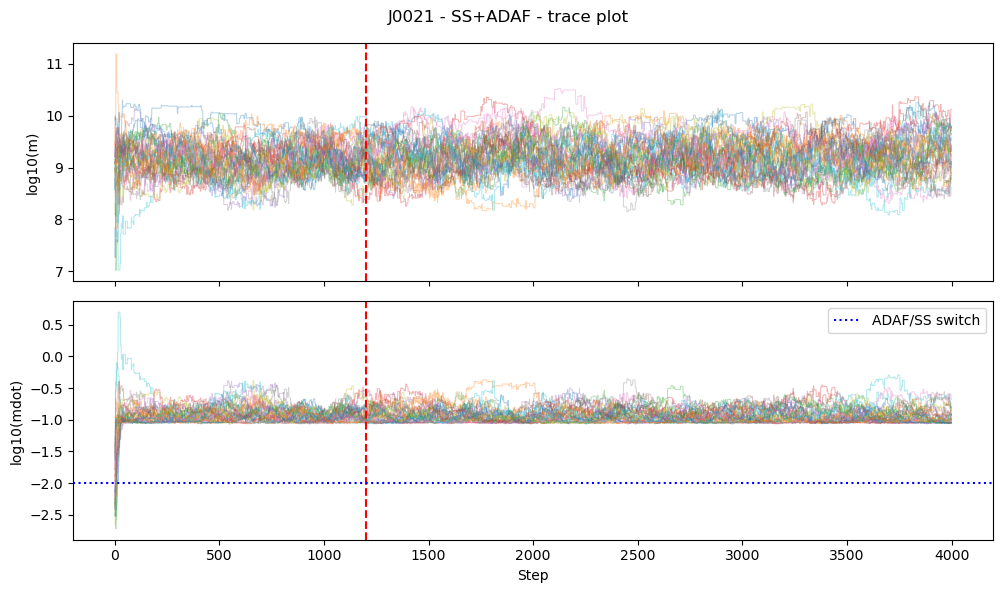

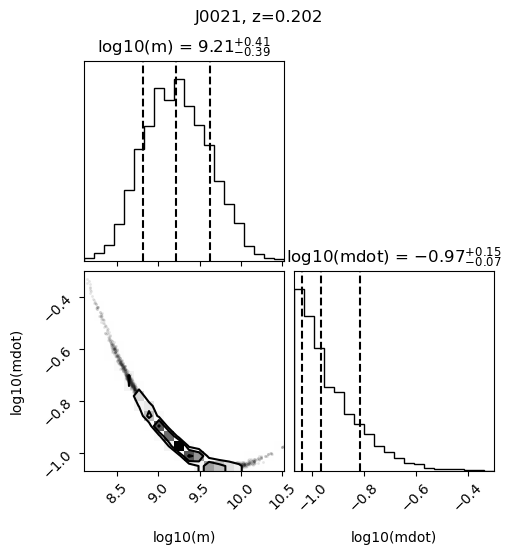


CHI2 LINEA PER LINEA AL PUNTO MEDIANO
logM median    = 9.212952
logmdot median = -0.966561
regime         = SS

Hb       | L_obs = 6.5693e+42 | L_mod = 5.9727e+42 | res = 2.96 sigma | chi2 = 8.76 | Cf_req = 1.0999e-01
Hg       | L_obs = 1.8676e+42 | L_mod = 2.8110e+42 | res = -3.80 sigma | chi2 = 14.42 | Cf_req = 6.6439e-02
Hd       | L_obs = 1.3434e+42 | L_mod = 1.5654e+42 | res = -2.40 sigma | chi2 = 5.76 | Cf_req = 8.5818e-02

CHI2 TOTALE = 28.94


,line_name,line_model,L_line_obs,sigma_L,L_line_mod,model_over_obs,residual_sigma,chi2_line,Cf_required,Q_H,L_ion
0,Hb,Balmer_CaseB,6.569277e+42,2.015364e+41,5.972744e+42,0.909194,2.959923,8.761146,0.109988,1.233060e+56,NaN
1,Hg,Balmer_CaseB,1.867612e+42,2.484523e+41,2.811002e+42,1.505132,-3.797068,14.417729,0.066439,1.233060e+56,NaN
2,Hd,Balmer_CaseB,1.343418e+42,9.248666e+40,1.565436e+42,1.165263,-2.400540,5.762593,0.085818,1.233060e+56,NaN



MINIMO CHI2 TROVATO NELLA GRIGLIA
logM       = 8.4114
logmdot    = -0.5570
M          = 2.5787e+08 Msun
mdot       = 2.7736e-01
chi2 totale = 28.9283
chi2 MgII   = nan
chi2 Hd     = 6.0154


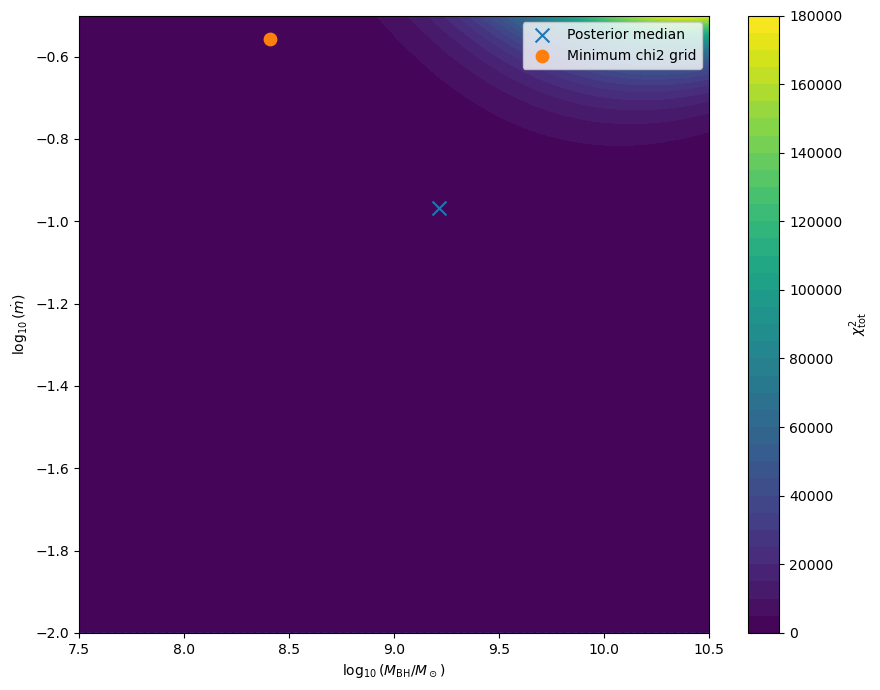

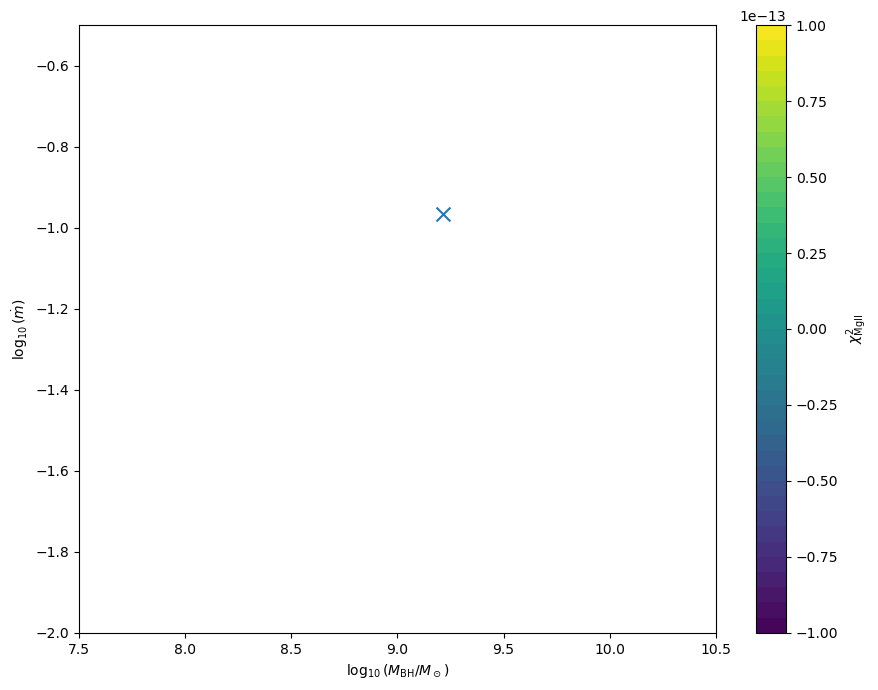

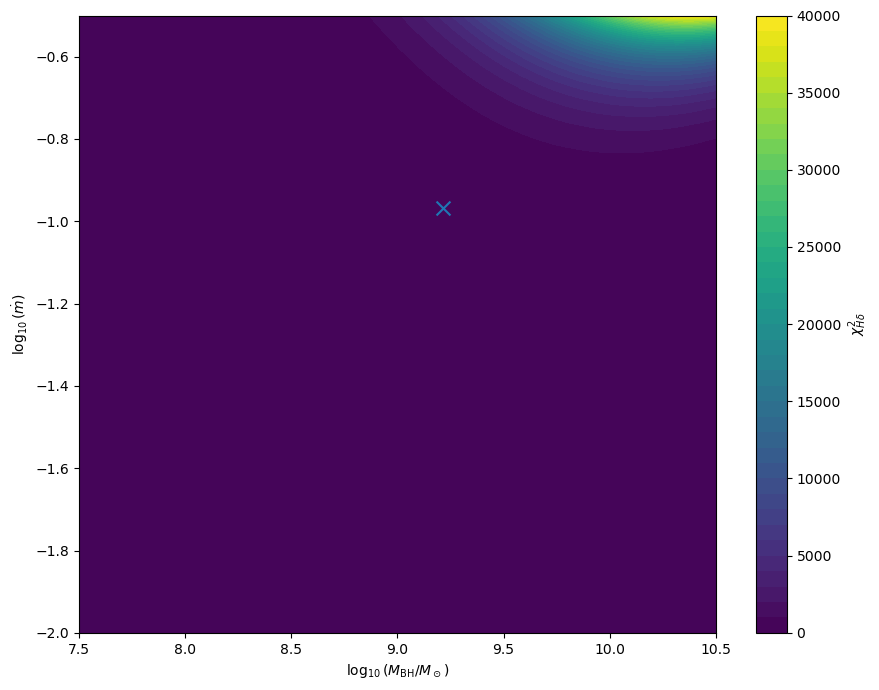


CHECK DEL MODELLO AI VALORI MEDIANI
logM median    = 9.212952
logmdot median = -0.966561
M median       = 1.632873e+09 Msun
mdot median    = 1.080038e-01
regime         = SS

Hb       | L_obs = 6.5693e+42 | L_mod = 5.9727e+42 | mod/obs = 9.0919e-01 | obs/mod = 1.0999e+00 | res = 2.96 sigma | Cf_req = 1.0999e-01
Hg       | L_obs = 1.8676e+42 | L_mod = 2.8110e+42 | mod/obs = 1.5051e+00 | obs/mod = 6.6439e-01 | res = -3.80 sigma | Cf_req = 6.6439e-02
Hd       | L_obs = 1.3434e+42 | L_mod = 1.5654e+42 | mod/obs = 1.1653e+00 | obs/mod = 8.5818e-01 | res = -2.40 sigma | Cf_req = 8.5818e-02


,line_name,line_model,L_line_obs,sigma_L,L_line_mod,model_over_obs,obs_over_model,residual_sigma,Cf_required,Q_H,L_ion
0,Hb,Balmer_CaseB,6.569277e+42,2.015364e+41,5.972744e+42,0.909194,1.099876,2.959923,0.109988,1.233060e+56,NaN
1,Hg,Balmer_CaseB,1.867612e+42,2.484523e+41,2.811002e+42,1.505132,0.664394,-3.797068,0.066439,1.233060e+56,NaN
2,Hd,Balmer_CaseB,1.343418e+42,9.248666e+40,1.565436e+42,1.165263,0.858175,-2.400540,0.085818,1.233060e+56,NaN


In [100]:
CFG = {

    # ------------------------------------------------------
    # Input files
    # ------------------------------------------------------

    "file_linee": "Tab_completa_revisione.csv",
    "file_transizioni": "dati.asc",

    # ------------------------------------------------------
    # Target blazar
    # ------------------------------------------------------

    "label_target": "J0021",

    #"exclude_lines": ["Hg"],

    # ------------------------------------------------------
    # ADAF / SS transition threshold
    #
    # Below 10^-2 -> ADAF regime
    # Above 10^-2 -> SS regime
    # ------------------------------------------------------

    "logmdot_switch": -2.0,

    # ------------------------------------------------------
    # Gaussian priors
    #
    # Values adopted from Paliya (2021)
    # ------------------------------------------------------

    "prior_logm_mu": 8.6,
    "prior_logm_sigma": 0.6,

    "prior_logmdot_mu": -1.9,
    "prior_logmdot_sigma": 0.4,


    # ------------------------------------------------------
    # Shakura-Sunyaev model parameters
    # ------------------------------------------------------

    # Radiative efficiency
    "eta": 0.083,

    # Number of radial grid points
    "Nr": 80,

    # Number of frequency grid points
    "Nnu_ss": 120,

    # Frequency range (Hz)
    "nu_min_ss": 1e13,
    "nu_max_ss": 1e17,

    # ------------------------------------------------------
    # ADAF model parameters
    # ------------------------------------------------------

    # Viscosity parameter
    "alfa": 0.3,

    # Inner and outer radii (in Schwarzschild units)
    "rmin": 3.0,
    "rmax": 1000.0,

    # Fraction of viscous heating deposited directly into electrons
    "delta": 0.0,

    # Gas-pressure fraction parameter
    "beta_adaf": 0.5,

    # ADAF structure coefficients
    "c1": 0.5,
    "c3": 0.3,

    # Electron temperature normalization
    "tnorm": 1.68e-10,

    # Frequency grid for ADAF spectra
    "Nnu_adaf": 120,
    "nu_min_adaf": 1e10,
    "nu_max_adaf": 1e17,

    # Initial guess for the nonlinear ADAF solver
    "root_y0": [0.5, 1.0, 0.99],

    # Numerical tolerance of the root solver
    "root_tol": 1e-10,

    # ------------------------------------------------------
    # Ionizing luminosity and BLR parameters
    # ------------------------------------------------------

    # Maximum frequency used in ionizing luminosity integration
    "nu_max_ion": 1e17,

    # Broad-Line Region covering factors
    "cf_blr_ss": 0.1,
    "cf_blr_adaf": 0.1,

    # Default relative uncertainty assigned when
    # no observational error is available
    "rel_err": 0.20,

    # ------------------------------------------------------
    # MCMC parameters
    # ------------------------------------------------------

    # Number of walkers
    "nwalkers": 32,

    # Total number of MCMC steps
    "nsteps": 4000,

    # Burn-in phase removed before analysis
    "burn_in": 1200,

    # Keep one sample every 'thin' steps
    "thin": 15,

    # ------------------------------------------------------
    # Initial walker distribution
    # ------------------------------------------------------

    # Initial guess for log10(MBH/Msun)
    "guess_logm": 9.0,

    # Initial guess for log10(mdot)
    "guess_logmdot": -2.0,

    # Width of the initial walker distribution
    # around the mass guess
    "spread_logm": 0.5,

    # Width of the initial walker distribution
    # around the accretion-rate guess
    "spread_logmdot": 0.5,

    # ------------------------------------------------------
    # Random seed
    # ------------------------------------------------------

    "random_seed": 42,
}


# ==========================================================
# RUN THE COMPLETE FIT
# ==========================================================

fit_results = fit_blazar_with_unified_mcmc(CFG)

"""
compare_old_new_balmer(
    log_black_hole_mass=11.068,
    log_accretion_rate=-3.051 ,
    df_transitions=fit_results["df_transitions"],
    df_observed=fit_results["df_observed"],
    cfg=CFG
)
"""

# ==========================================================
# CHECK CHI2 LINEA PER LINEA + GRIGLIA M, MDOT
# ==========================================================

summary = fit_results["summary"]

logM_med = summary["log_black_hole_mass_median"]
logmdot_med = summary["log_accretion_rate_median"]

# ==========================================================
# 1) CHI2 AL PUNTO MEDIANO
# ==========================================================

df_model_med, regime_med = predict_lines_from_unified_model(
    log_black_hole_mass=logM_med,
    log_accretion_rate=logmdot_med,
    df_transitions=fit_results["df_transitions"],
    cfg=CFG
)

df_chi = fit_results["df_observed"].merge(
    df_model_med[
        [
            "line_name",
            "L_line_mod",
            "L_line_without_cf",
            "Q_H",
            "L_ion",
            "line_model"
        ]
    ],
    on="line_name",
    how="inner"
)

df_chi["residual_sigma"] = (
    (
        df_chi["L_line_obs"]
        - df_chi["L_line_mod"]
    )
    / df_chi["sigma_L"]
)

df_chi["chi2_line"] = (
    df_chi["residual_sigma"]**2
)

df_chi["model_over_obs"] = (
    df_chi["L_line_mod"]
    / df_chi["L_line_obs"]
)

df_chi["Cf_required"] = (
    0.1
    * df_chi["L_line_obs"]
    / df_chi["L_line_mod"]
)

chi2_tot = df_chi["chi2_line"].sum()

print()
print("=" * 100)
print("CHI2 LINEA PER LINEA AL PUNTO MEDIANO")
print("=" * 100)

print(f"logM median    = {logM_med:.6f}")
print(f"logmdot median = {logmdot_med:.6f}")
print(f"regime         = {regime_med}")
print()

for _, row in df_chi.iterrows():

    print(
        f"{row['line_name']:8s} | "
        f"L_obs = {row['L_line_obs']:.4e} | "
        f"L_mod = {row['L_line_mod']:.4e} | "
        f"res = {row['residual_sigma']:.2f} sigma | "
        f"chi2 = {row['chi2_line']:.2f} | "
        f"Cf_req = {row['Cf_required']:.4e}"
    )

print()
print(f"CHI2 TOTALE = {chi2_tot:.2f}")
print("=" * 100)

display(
    df_chi[
        [
            "line_name",
            "line_model",
            "L_line_obs",
            "sigma_L",
            "L_line_mod",
            "model_over_obs",
            "residual_sigma",
            "chi2_line",
            "Cf_required",
            "Q_H",
            "L_ion"
        ]
    ]
)


# ==========================================================
# 2) GRIGLIA IN logM E logmdot
# ==========================================================

logM_grid = np.linspace(
    7.5,
    10.5,
    80
)

logmdot_grid = np.linspace(
    -2.0,
    -0.5,
    80
)

chi2_grid = np.full(
    (
        len(logmdot_grid),
        len(logM_grid)
    ),
    np.nan
)

chi2_MgII_grid = np.full_like(
    chi2_grid,
    np.nan
)

chi2_Hd_grid = np.full_like(
    chi2_grid,
    np.nan
)

for i, logmdot in enumerate(logmdot_grid):

    for j, logM in enumerate(logM_grid):

        try:

            df_model, regime = predict_lines_from_unified_model(
                log_black_hole_mass=logM,
                log_accretion_rate=logmdot,
                df_transitions=fit_results["df_transitions"],
                cfg=CFG
            )

        except Exception:

            continue

        df_tmp = fit_results["df_observed"].merge(
            df_model[
                [
                    "line_name",
                    "L_line_mod"
                ]
            ],
            on="line_name",
            how="inner"
        )

        if len(df_tmp) == 0:
            continue

        df_tmp["chi2_line"] = (
            (
                df_tmp["L_line_obs"]
                - df_tmp["L_line_mod"]
            )
            / df_tmp["sigma_L"]
        )**2

        chi2_grid[i, j] = (
            df_tmp["chi2_line"].sum()
        )

        row_mg = df_tmp[
            df_tmp["line_name"] == "MgII"
        ]

        if len(row_mg) > 0:

            chi2_MgII_grid[i, j] = (
                row_mg.iloc[0]["chi2_line"]
            )

        row_hd = df_tmp[
            df_tmp["line_name"] == "Hd"
        ]

        if len(row_hd) > 0:

            chi2_Hd_grid[i, j] = (
                row_hd.iloc[0]["chi2_line"]
            )


# ==========================================================
# 3) TROVO IL MINIMO DELLA GRIGLIA
# ==========================================================

if np.any(np.isfinite(chi2_grid)):

    idx_min = np.nanargmin(
        chi2_grid
    )

    i_min, j_min = np.unravel_index(
        idx_min,
        chi2_grid.shape
    )

    best_logmdot_grid = (
        logmdot_grid[i_min]
    )

    best_logM_grid = (
        logM_grid[j_min]
    )

    best_chi2_grid = (
        chi2_grid[i_min, j_min]
    )

    print()
    print("=" * 100)
    print("MINIMO CHI2 TROVATO NELLA GRIGLIA")
    print("=" * 100)

    print(
        f"logM       = {best_logM_grid:.4f}"
    )

    print(
        f"logmdot    = {best_logmdot_grid:.4f}"
    )

    print(
        f"M          = {10**best_logM_grid:.4e} Msun"
    )

    print(
        f"mdot       = {10**best_logmdot_grid:.4e}"
    )

    print(
        f"chi2 totale = {best_chi2_grid:.4f}"
    )

    print(
        f"chi2 MgII   = "
        f"{chi2_MgII_grid[i_min, j_min]:.4f}"
    )

    print(
        f"chi2 Hd     = "
        f"{chi2_Hd_grid[i_min, j_min]:.4f}"
    )

    print("=" * 100)


# ==========================================================
# 4) MAPPA CHI2 TOTALE
# ==========================================================

plt.figure(
    figsize=(9, 7)
)

plt.contourf(
    logM_grid,
    logmdot_grid,
    chi2_grid,
    levels=40
)

plt.colorbar(
    label=r"$\chi^2_{\rm tot}$"
)

plt.scatter(
    logM_med,
    logmdot_med,
    marker="x",
    s=100,
    label="Posterior median"
)

plt.scatter(
    best_logM_grid,
    best_logmdot_grid,
    marker="o",
    s=80,
    label="Minimum chi2 grid"
)

plt.axhline(
    CFG["logmdot_switch"],
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    r"$\log_{10}(M_{\rm BH}/M_\odot)$"
)

plt.ylabel(
    r"$\log_{10}(\dot{m})$"
)

plt.legend()

plt.tight_layout()
plt.show()


# ==========================================================
# 5) MAPPA CHI2 SOLO MgII
# ==========================================================

plt.figure(
    figsize=(9, 7)
)

plt.contourf(
    logM_grid,
    logmdot_grid,
    chi2_MgII_grid,
    levels=40
)

plt.colorbar(
    label=r"$\chi^2_{\rm MgII}$"
)

plt.scatter(
    logM_med,
    logmdot_med,
    marker="x",
    s=100
)

plt.xlabel(
    r"$\log_{10}(M_{\rm BH}/M_\odot)$"
)

plt.ylabel(
    r"$\log_{10}(\dot{m})$"
)

plt.tight_layout()
plt.show()


# ==========================================================
# 6) MAPPA CHI2 SOLO Hd
# ==========================================================

plt.figure(
    figsize=(9, 7)
)

plt.contourf(
    logM_grid,
    logmdot_grid,
    chi2_Hd_grid,
    levels=40
)

plt.colorbar(
    label=r"$\chi^2_{H\delta}$"
)

plt.scatter(
    logM_med,
    logmdot_med,
    marker="x",
    s=100
)

plt.xlabel(
    r"$\log_{10}(M_{\rm BH}/M_\odot)$"
)

plt.ylabel(
    r"$\log_{10}(\dot{m})$"
)

plt.tight_layout()
plt.show()


# ==========================================================
# CHECK DEL FIT AI VALORI MEDIANI
# ==========================================================

summary = fit_results["summary"]

logM_median = summary["log_black_hole_mass_median"]
logmdot_median = summary["log_accretion_rate_median"]

df_model_median, regime_median = predict_lines_from_unified_model(
    log_black_hole_mass=logM_median,
    log_accretion_rate=logmdot_median,
    df_transitions=fit_results["df_transitions"],
    cfg=CFG
)

df_check = fit_results["df_observed"].merge(
    df_model_median[
        [
            "line_name",
            "L_line_mod",
            "L_line_without_cf",
            "Q_H",
            "L_ion",
            "line_model"
        ]
    ],
    on="line_name",
    how="inner"
)

df_check["model_over_obs"] = (
    df_check["L_line_mod"]
    / df_check["L_line_obs"]
)

df_check["obs_over_model"] = (
    df_check["L_line_obs"]
    / df_check["L_line_mod"]
)

df_check["residual"] = (
    df_check["L_line_obs"]
    - df_check["L_line_mod"]
)

df_check["residual_sigma"] = (
    df_check["residual"]
    / df_check["sigma_L"]
)

df_check["Cf_required"] = (
    0.1
    * df_check["obs_over_model"]
)

print()
print("=" * 100)
print("CHECK DEL MODELLO AI VALORI MEDIANI")
print("=" * 100)

print(
    f"logM median    = {logM_median:.6f}"
)

print(
    f"logmdot median = {logmdot_median:.6f}"
)

print(
    f"M median       = {10**logM_median:.6e} Msun"
)

print(
    f"mdot median    = {10**logmdot_median:.6e}"
)

print(
    f"regime         = {regime_median}"
)

print()

for _, row in df_check.iterrows():

    print(
        f"{row['line_name']:8s} | "
        f"L_obs = {row['L_line_obs']:.4e} | "
        f"L_mod = {row['L_line_mod']:.4e} | "
        f"mod/obs = {row['model_over_obs']:.4e} | "
        f"obs/mod = {row['obs_over_model']:.4e} | "
        f"res = {row['residual_sigma']:.2f} sigma | "
        f"Cf_req = {row['Cf_required']:.4e}"
    )

print("=" * 100)

display(
    df_check[
        [
            "line_name",
            "line_model",
            "L_line_obs",
            "sigma_L",
            "L_line_mod",
            "model_over_obs",
            "obs_over_model",
            "residual_sigma",
            "Cf_required",
            "Q_H",
            "L_ion"
        ]
    ]
)